In [2]:
import pandas as pd
import numpy as np

In [5]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_df = pd.read_csv(url, header=None, names=columns)

In [8]:
print("Dataset Shape (rows, cols):", pima_df.shape)
print("\nFirst 3 rows of raw dataset:")
print(pima_df.head(3))

Dataset Shape (rows, cols): (768, 9)

First 3 rows of raw dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  


In [11]:
zero_counts = (pima_df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum()
print("\nInvalid Zero Values per column:\n", zero_counts)


Invalid Zero Values per column:
 Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [14]:
from sklearn.impute import SimpleImputer

In [17]:
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
pima_df[cols_to_impute] = pima_df[cols_to_impute].replace(0, np.nan)


In [20]:
print("Missing values after marking zeros:\n", pima_df.isnull().sum())

Missing values after marking zeros:
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [23]:
imputer = SimpleImputer(strategy='median')
pima_df[cols_to_impute] = imputer.fit_transform(pima_df[cols_to_impute])

print("\nMissing values after statistical median imputation:\n", pima_df.isnull().sum())



Missing values after statistical median imputation:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [28]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [31]:

features = columns[:-1]
X = pima_df[features]

In [34]:
min_max_scaler = MinMaxScaler()
X_normalized = min_max_scaler.fit_transform(X)
print("Normalized Range Boundaries (Min/Max):", X_normalized.min(), "to", X_normalized.max())

Normalized Range Boundaries (Min/Max): 0.0 to 1.0000000000000002


In [37]:
standard_scaler = StandardScaler()
X_standardized = standard_scaler.fit_transform(X)
print("Standardized Mean (approx 0):", round(X_standardized.mean(), 4))
print("Standardized Std Dev (approx 1):", round(X_standardized.std(), 4))

Standardized Mean (approx 0): 0.0
Standardized Std Dev (approx 1): 1.0


In [40]:
from sklearn.preprocessing import PowerTransformer

In [43]:
original_skew = pima_df['Insulin'].skew()
print("Original skewness coefficient of 'Insulin':", round(original_skew, 4))

Original skewness coefficient of 'Insulin': 3.38


In [46]:
power_transformer = PowerTransformer(method='yeo-johnson')
insulin_transformed = power_transformer.fit_transform(pima_df[['Insulin']])


In [49]:
transformed_skew = pd.Series(insulin_transformed.flatten()).skew()
print("Skewness coefficient after Power Transformation:", round(transformed_skew, 4))

Skewness coefficient after Power Transformation: 0.0276


In [52]:
processed_pima_df = pd.DataFrame(data=X_standardized, columns=features)
processed_pima_df['Outcome'] = pima_df['Outcome']

In [55]:
processed_pima_df.to_csv("processed_pima_diabetes.csv", index=False)
print("Processed Pima dataset exported successfully to 'processed_pima_diabetes.csv'. Shape:", processed_pima_df.shape)

Processed Pima dataset exported successfully to 'processed_pima_diabetes.csv'. Shape: (768, 9)


In [58]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [61]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar_features = [f"F_{i}" for i in range(1, 61)]
sonar_columns = sonar_features + ['Class']
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [64]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [67]:
X_sonar = sonar_df[sonar_features]

In [70]:
scaler = StandardScaler()
X_sonar_scaled = scaler.fit_transform(X_sonar)

In [73]:
print("Standardized features shape:", X_sonar_scaled.shape)

Standardized features shape: (208, 60)


In [76]:
from sklearn.decomposition import PCA


In [79]:
pca_90 = PCA(n_components=0.90, random_state=42)
X_pca_90 = pca_90.fit_transform(X_sonar_scaled)

In [82]:
print("Original dimensions count:", X_sonar_scaled.shape[1])
print("Reduced dimensions count (to preserve 90% variance):", X_pca_90.shape[1])

Original dimensions count: 60
Reduced dimensions count (to preserve 90% variance): 22


In [91]:
import matplotlib.pyplot as plt
import numpy as np

In [93]:
pca_full = PCA(random_state=42)
pca_full.fit(X_sonar_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

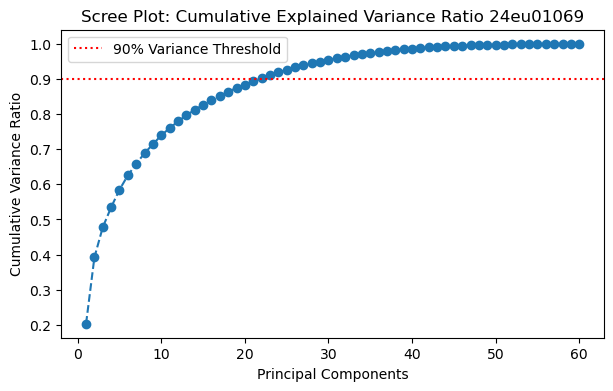

In [95]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Variance Threshold')
plt.title("Scree Plot: Cumulative Explained Variance Ratio 24eu01069")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance Ratio")
plt.legend()
plt.show()

In [107]:
from sklearn.manifold import TSNE
import seaborn as sns

In [109]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_sonar_scaled)

In [111]:
tsne_df = pd.DataFrame(X_tsne, columns=['Dim_1', 'Dim_2'])
tsne_df['Class'] = sonar_df['Class']

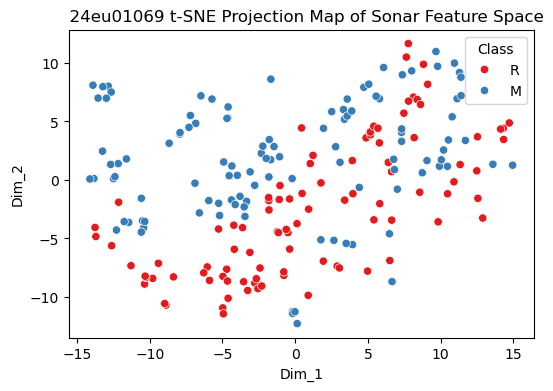

In [113]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2', hue='Class', palette='Set1')
plt.title("  24eu01069 t-SNE Projection Map of Sonar Feature Space")
plt.show()

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [119]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_sonar_scaled, sonar_df['Class_numeric'], test_size=0.3, random_state=42)
lr_raw = LogisticRegression()
lr_raw.fit(X_train_raw, y_train)
acc_raw = accuracy_score(y_test, lr_raw.predict(X_test_raw))

In [122]:
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca_90, sonar_df['Class_numeric'], test_size=0.3, random_state=42)
lr_pca = LogisticRegression()
lr_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, lr_pca.predict(X_test_pca))

In [125]:
print(f"Accuracy using all 60 scaled features: {acc_raw * 100:.2f}%")
print(f"Accuracy using {X_pca_90.shape[1]} PCA components:  {acc_pca * 100:.2f}%")

Accuracy using all 60 scaled features: 76.19%
Accuracy using 22 PCA components:  87.30%


In [128]:
from sklearn.feature_selection import SelectKBest, f_classif

In [131]:
selector = SelectKBest(score_func=f_classif, k=4)
selector.fit(X_standardized, pima_df['Outcome'])

SelectKBest(k=4)

In [134]:
anova_scores = pd.DataFrame({'Feature': features, 'F-Score': selector.scores_}).sort_values(by='F-Score', ascending=False)
print("ANOVA F-Test Scores:\n", anova_scores)

ANOVA F-Test Scores:
                     Feature     F-Score
1                   Glucose  245.667855
5                       BMI   82.629271
7                       Age   46.140611
0               Pregnancies   39.670227
3             SkinThickness   37.078538
4                   Insulin   33.190796
6  DiabetesPedigreeFunction   23.871300
2             BloodPressure   21.631580


In [137]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [140]:
estimator = LogisticRegression()
rfe = RFE(estimator=estimator, n_features_to_select=4)
rfe.fit(X_standardized, pima_df['Outcome'])

RFE(estimator=LogisticRegression(), n_features_to_select=4)

In [143]:
rfe_support = pd.DataFrame({'Feature': features, 'Selected': rfe.support_, 'Ranking': rfe.ranking_}).sort_values(by='Ranking')
print("RFE Selected Features:\n", rfe_support)

RFE Selected Features:
                     Feature  Selected  Ranking
0               Pregnancies      True        1
1                   Glucose      True        1
5                       BMI      True        1
6  DiabetesPedigreeFunction      True        1
7                       Age     False        2
2             BloodPressure     False        3
4                   Insulin     False        4
3             SkinThickness     False        5


In [146]:
from sklearn.linear_model import LogisticRegression

In [149]:
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42)
lasso.fit(X_standardized, pima_df['Outcome'])

LogisticRegression(C=0.5, penalty='l1', random_state=42, solver='liblinear')

In [152]:
lasso_coefs = pd.DataFrame({'Feature': features, 'Coefficient': lasso.coef_[0]}).sort_values(by='Coefficient', key=abs, ascending=False)
print("Lasso Regularization Coefficients:\n", lasso_coefs)


Lasso Regularization Coefficients:
                     Feature  Coefficient
1                   Glucose     1.106412
5                       BMI     0.611338
0               Pregnancies     0.399515
6  DiabetesPedigreeFunction     0.269034
7                       Age     0.134767
2             BloodPressure    -0.073190
4                   Insulin    -0.067230
3             SkinThickness     0.019400


In [170]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [172]:
warnings.filterwarnings("ignore")

In [174]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X, pima_df['Outcome']) 

RandomForestClassifier(random_state=42)

In [176]:
importances = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
print("Random Forest Feature Importances:\n", importances)

Random Forest Feature Importances:
                     Feature  Importance
1                   Glucose    0.263715
5                       BMI    0.167470
7                       Age    0.127208
6  DiabetesPedigreeFunction    0.124075
4                   Insulin    0.084843
2             BloodPressure    0.082722
0               Pregnancies    0.079268
3             SkinThickness    0.070699


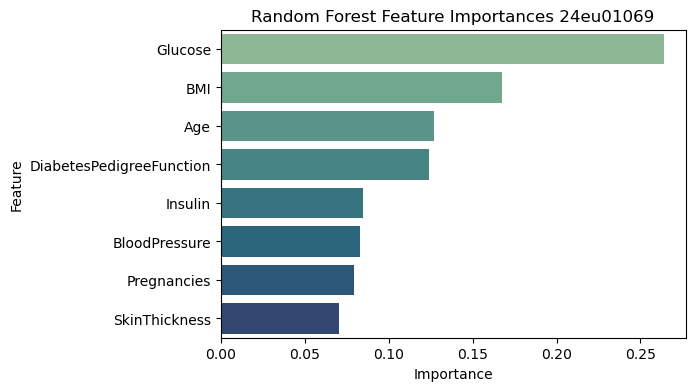

In [178]:
plt.figure(figsize=(6, 4))
sns.barplot(data=importances, x='Importance', y='Feature', palette='crest')
plt.title("Random Forest Feature Importances 24eu01069")
plt.show()

In [181]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [184]:
X_train, X_test, y_train_p, y_test_p = train_test_split(X, pima_df['Outcome'], test_size=0.3, random_state=42)

In [187]:
rf_full = RandomForestClassifier(random_state=42)
rf_full.fit(X_train, y_train_p)
preds_full = rf_full.predict(X_test)

In [190]:
top_4_cols = importances.head(4)['Feature'].tolist()
X_train_sub = X_train[top_4_cols]
X_test_sub = X_test[top_4_cols]

In [193]:
rf_sub = RandomForestClassifier(random_state=42)
rf_sub.fit(X_train_sub, y_train_p)
preds_sub = rf_sub.predict(X_test_sub)

In [196]:
print("--- CLASSIFICATION REPORT: ALL FEATURES (8 features) ---")
print(classification_report(y_test_p, preds_full))

print("\n--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 features) ---")
print(classification_report(y_test_p, preds_sub))


--- CLASSIFICATION REPORT: ALL FEATURES (8 features) ---
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       151
           1       0.63      0.66      0.65        80

    accuracy                           0.75       231
   macro avg       0.72      0.73      0.73       231
weighted avg       0.75      0.75      0.75       231


--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 features) ---
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       151
           1       0.60      0.68      0.64        80

    accuracy                           0.73       231
   macro avg       0.71      0.72      0.71       231
weighted avg       0.74      0.73      0.73       231

